<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 61 · Sampling &amp; Data Collection</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Why We Sample 🎯</div>
  <div style="font-size:15px;color:#fff1f2;max-width:740px;line-height:1.6">Measuring everyone is rarely possible. A well-drawn sample stands in for the whole population, and its error shrinks in a predictable way. We will see why a small random sample beats a huge biased one.</div>
  <div style="margin-top:16px;font-size:13px;color:#fecdd3">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
ROSE="#e11d48"; DEEP="#be123c"; LIGHT="#fb7185"; INK="#1a2138"; GRID="#e6e9f2"; TEAL="#0d9488"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
rng = np.random.default_rng(61)

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 1 · A SAMPLE STANDS IN FOR THE POPULATION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One million people, measured by a thousand</div>
<div style="color:#4a5578;margin-top:6px">We build a population of 1,000,000 incomes (right-skewed, like the real world). Computing the mean of ALL of them is the census. Then we draw a single sample of 1,000 and see how close its mean lands.</div>
</div>

In [2]:
# a realistic right-skewed population: lognormal incomes
POP = rng.lognormal(mean=10.8, sigma=0.6, size=1_000_000)
mu = POP.mean()
print(f"POPULATION (the census): N=1,000,000, true mean income = ${mu:,.0f}, sd = ${POP.std():,.0f}")
sample = rng.choice(POP, size=1000, replace=False)
xbar = sample.mean()
print(f"ONE SAMPLE of n=1,000: sample mean = ${xbar:,.0f}")
print(f"off by ${abs(xbar-mu):,.0f}  ({abs(xbar-mu)/mu*100:.2f}% of the truth), measuring 0.1% of the people")

POPULATION (the census): N=1,000,000, true mean income = $58,678, sd = $38,551
ONE SAMPLE of n=1,000: sample mean = $57,998
off by $680  (1.16% of the truth), measuring 0.1% of the people


A sample one-thousandth the size of the population lands within a percent or two of the true mean. That is the whole promise of sampling: a small, well-drawn subset carries almost all the information about the whole.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 2 · SAMPLING ERROR SHRINKS LIKE 1/&#8730;n</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Bigger samples, predictably tighter</div>
<div style="color:#4a5578;margin-top:6px">Even a perfect random sample misses by a little. That miss is the standard error, SE = sigma/sqrt(n). We draw 2,000 samples at each size and watch the spread of the sample means collapse as n grows.</div>
</div>

In [3]:
sigma = POP.std()
print(f"{'n':>6} | {'observed SE':>12} | {'sigma/sqrt(n)':>13}")
for n in [10, 30, 100, 500, 2000]:
    means = np.array([rng.choice(POP, n, replace=False).mean() for _ in range(2000)])
    print(f"{n:>6} | {means.std():>12,.0f} | {sigma/np.sqrt(n):>13,.0f}")
print("\nthe observed spread tracks sigma/sqrt(n): quadruple n to halve the error")

     n |  observed SE | sigma/sqrt(n)
    10 |       11,992 |        12,191
    30 |        7,129 |         7,038
   100 |        3,865 |         3,855
   500 |        1,702 |         1,724
  2000 |          849 |           862

the observed spread tracks sigma/sqrt(n): quadruple n to halve the error


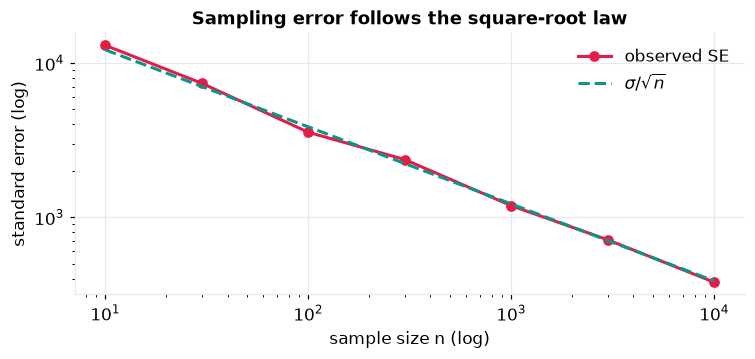

In [4]:
ns = np.array([10,30,100,300,1000,3000,10000])
ses = np.array([np.array([rng.choice(POP,n,replace=False).mean() for _ in range(400)]).std() for n in ns])
fig,ax=plt.subplots(figsize=(7,3.4))
ax.plot(ns, ses, "o-", color=ROSE, lw=2, label="observed SE")
ax.plot(ns, sigma/np.sqrt(ns), "--", color=TEAL, lw=2, label=r"$\sigma/\sqrt{n}$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("sample size n (log)"); ax.set_ylabel("standard error (log)")
ax.set_title("Sampling error follows the square-root law"); ax.legend()
plt.tight_layout(); plt.show()

The error falls like 1/&#8730;n, a straight line on log-log axes. This is the engine of every confidence interval: you can buy any precision you like, but the price is quadratic, four times the data for half the error.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 3 · THE SAMPLE FRACTION BARELY MATTERS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">1,000 from 10,000 is as good as 1,000 from a billion</div>
<div style="color:#4a5578;margin-top:6px">A common myth is that you must sample a large FRACTION of the population. In fact what matters is the sample SIZE n, not n/N. We draw n=1,000 from populations of wildly different sizes and compare.</div>
</div>

In [5]:
n = 1000
for N in [10_000, 100_000, 1_000_000]:
    pop = rng.lognormal(10.8, 0.6, size=N)
    se = np.array([rng.choice(pop, n, replace=False).mean() for _ in range(1000)]).std()
    print(f"population N={N:>9,}: sampling {n/N*100:6.2f}% of it -> SE = ${se:,.0f}")
print("\nthe standard error is essentially the same: precision rides on n, not on the fraction sampled")

population N=   10,000: sampling  10.00% of it -> SE = $1,166
population N=  100,000: sampling   1.00% of it -> SE = $1,188
population N=1,000,000: sampling   0.10% of it -> SE = $1,208

the standard error is essentially the same: precision rides on n, not on the fraction sampled


A national poll of 1,000 people is just as accurate for a country of 300 million as for a town of 30,000. The standard error depends on n, not on how big a slice of the population you took, which is why national polls can be so small.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 4 · A SMALL RANDOM SAMPLE BEATS A HUGE BIASED ONE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The 1936 Literary Digest lesson</div>
<div style="color:#4a5578;margin-top:6px">In 1936 the Literary Digest polled 2.4 million people and predicted Landon would beat Roosevelt. Gallup polled 50,000 and got it right. The Digest's list (car and phone owners) was not representative. We recreate the effect.</div>
</div>

In [6]:
# population: true support for candidate A is 55%
true_support = 0.55
voters = (rng.random(1_000_000) < true_support).astype(int)
# wealth correlates with NOT supporting A; the biased frame over-samples the wealthy
wealth = rng.random(1_000_000)
voters = ((rng.random(1_000_000) < (true_support - 0.18*(wealth-0.5)*2))).astype(int)
print(f"TRUE support for A in the population: {voters.mean()*100:.1f}%\n")
# huge biased sample: only the wealthy half is reachable
reachable = np.where(wealth > 0.5)[0]
biased = voters[rng.choice(reachable, 240_000, replace=False)]
print(f"Literary Digest (biased frame, n=240,000): estimate = {biased.mean()*100:.1f}%  -> WRONG")
# small simple random sample from everyone
srs = voters[rng.choice(1_000_000, 2_000, replace=False)]
print(f"Gallup (random sample, n=2,000):         estimate = {srs.mean()*100:.1f}%  -> right")
print("\n120x more data could not fix a biased frame; representativeness beats size")

TRUE support for A in the population: 55.1%

Literary Digest (biased frame, n=240,000): estimate = 46.1%  -> WRONG
Gallup (random sample, n=2,000):         estimate = 53.8%  -> right

120x more data could not fix a biased frame; representativeness beats size


The biased sample is wrong no matter how large it is, because its error is <em>systematic</em>, not random. Adding more biased data just sharpens a wrong answer. A representative sample, even a small one, is worth more than a huge convenient one.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 5 · COST VS PRECISION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Diminishing returns set in fast</div>
<div style="color:#4a5578;margin-top:6px">Because precision grows with sqrt(n), each extra unit of accuracy costs more than the last. Plotting precision against sample size shows why most surveys stop at a few thousand.</div>
</div>

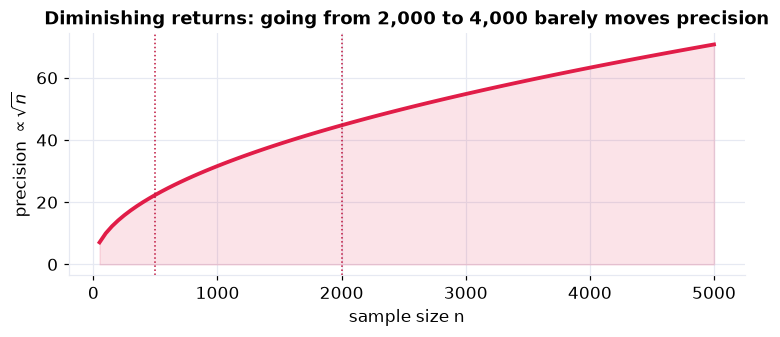

doubling n from 2,000 to 4,000 raises precision by only 41%


In [7]:
ns = np.arange(50, 5001, 50)
precision = np.sqrt(ns)            # precision ~ 1/SE ~ sqrt(n)
fig,ax=plt.subplots(figsize=(7,3.2))
ax.plot(ns, precision, color=ROSE, lw=2.5)
ax.fill_between(ns, precision, color=ROSE, alpha=0.12)
for mark in [500, 2000]:
    ax.axvline(mark, color=DEEP, ls=":", lw=1)
ax.set_xlabel("sample size n"); ax.set_ylabel(r"precision $\propto\sqrt{n}$")
ax.set_title("Diminishing returns: going from 2,000 to 4,000 barely moves precision")
plt.tight_layout(); plt.show()
print("doubling n from 2,000 to 4,000 raises precision by only", f"{(np.sqrt(4000)/np.sqrt(2000)-1)*100:.0f}%")

The curve flattens quickly. Past a few thousand observations, more data buys very little extra accuracy, so the real questions become <em>representativeness</em> and <em>cost</em>, the subjects of the chapters ahead.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Why we sample</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">A sample of a thousand pinned a million-person mean to within a percent or two. Its error falls like sigma/sqrt(n), depends on n and not the fraction sampled, and reaches diminishing returns fast. Above all, a small representative sample beats a huge biased one, because bias is systematic error that more data cannot cure. Next: HOW to draw a representative sample.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>